# Condiciones iniciales de los experimentos de mosto natural (LAB001–LAB018): análisis cuantitativo descriptivo

**Tipo de análisis**: estrictamente descriptivo y reproducible. **No se ejecuta ningún fitting,
optimizador ni recalibración**; no se modifican datasets, loaders, notebooks ni resultados
existentes. Este notebook es un artefacto nuevo y sus salidas son 4 CSV en
`laboratory_2026/results/natural_must_initial_conditions_analysis/`.

Base: `docs/natural_must_temporal_audit_LAB001_018.md` (auditoría de solo lectura, 2026-09-09),
usada como **mapa** de fuentes. Todo valor que entra en las estadísticas se relee aquí desde la
**fuente primaria** (workbooks/CSV originales) y se verifica contra
`results/estimability_historical_natural/batch_summary.csv` (ICs realmente usadas por el ajuste
θ_natural).

Premisa externa (investigador): todos los LAB usan el **mismo mosto madre**. El repositorio solo
documenta ese vínculo para LAB013–LAB015 (triplicado) y LAB016–018 (ICs heredadas). Este análisis
verifica cuantitativamente qué tan "comunes" son las condiciones iniciales **químicas medidas**.

Convención de evidencia: [HECHO VERIFICADO] respaldado por archivo/dato; [RESULTADO DESCRIPTIVO]
salida directa de este notebook; [INTERPRETACIÓN] lectura razonada; [NO DOCUMENTADO] /
[CONFLICTO] según auditoría.

## 1. Configuración, constantes y metadata de procedencia

Constantes tomadas del código del repositorio (auditoría, FASE 6/7):
- `ETHANOL_G_L_PER_PERCENT_VV = 7.8924` (`shared/new_must_data_loader.py:53-54`)
- `MG_L_TO_KG_M3 = 1e-3` (YAN mg/L → N kg/m³, loader `:58, :245`)
- `MCELLSML_TO_KGM3 = 0.03` (Oculyze Mcél/mL → kg/m³, 30 pg/célula, loader `:55-57`)
- `YAN_NH3_TO_N = 0.82` (fórmula del workbook xthiol `00_Resumen`/`Diccionario_mapeo`: YAN = PAN + 0.82·Amonio)

La metadata temporal (fechas de inoculación, Δt química–inoculación, grupos) proviene de la
auditoría (TABLA A/D) y se declara explícitamente con su fuente; no se re-deriva aquí.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

ETHANOL_G_L_PER_PERCENT_VV = 7.8924   # g/L por % v/v  (loader :53-54)
MG_L_TO_KG_M3 = 1e-3                  # YAN [mg/L] -> N [kg/m3] (loader :58,:245)
MCELLSML_TO_KGM3 = 0.03               # Mcel/mL -> kg/m3 (loader :55-57)
YAN_NH3_TO_N = 0.82                   # YAN = PAN + 0.82*Amonio (workbook xthiol)

NB_DIR = os.getcwd()                                   # .../laboratory_2026/notebooks
FM = os.path.abspath(os.path.join(NB_DIR, "..", "..")) # fermentation_model

XTHIOL    = os.path.join(FM, "data", "Laboratorio 2026", "Vendimia_2026", "mosto_natural_xthiol.xlsx")
PLANILLA  = os.path.join(FM, "data", "Piloto 2026", "Lotes1a3", "raw", "Planilla_Maestra_ID_2026_14_07_26.xlsx")
Y15_CSV   = os.path.join(FM, "data", "mem2026", "LAB013-015", "Y15_LAB013-015.csv")
OFF16_XLS = os.path.join(FM, "data", "mem2026", "LAB016-018", "LAB016-018-offline-measurements.xlsx")
OCU_DIRS  = {n: os.path.join(FM, "data", "mem2026", g, f"LAB0{n}_OCULYZE", "report.csv")
             for n, g in zip(range(13, 19), ["LAB013-015"]*3 + ["LAB016-018"]*3)}
BATCH_SUMMARY = os.path.join(FM, "laboratory_2026", "results", "estimability_historical_natural", "batch_summary.csv")
OUT_DIR  = os.path.join(FM, "laboratory_2026", "results", "natural_must_initial_conditions_analysis")
os.makedirs(OUT_DIR, exist_ok=True)

for p in [XTHIOL, PLANILLA, Y15_CSV, OFF16_XLS, BATCH_SUMMARY] + list(OCU_DIRS.values()):
    assert os.path.exists(p), p
print("Fuentes presentes. OUT_DIR =", OUT_DIR)

# ---- Metadata de grupos / procedencia (fuente: auditoría TABLA A y D) ----
# quimica_dt: fecha-hora de la medición que define cada IC medida
# delta_t   : t_quimica - t_inoculacion [h] (NaN si la inoculación no está documentada con hora)
GROUPS = {
    "LAB001": dict(grupo="G1_Lote1_Vendimia",   fecha="2026-03-25", sp0=18, nutricion="Springferm+FDA en inoculación + pulso 1040",
                   inoc="2026-03-25 18:00", inoc_src="Planilla 03_Eventos (ejecución) + Maestro hora", chem_dt="2026-03-25 16:00", delta_t=-2.0,
                   nota="Química L-01 pre-inóculo (hito 04_Muestreo_MEF)"),
    "LAB002": dict(grupo="G1_Lote1_Vendimia",   fecha="2026-03-25", sp0=18, nutricion="ídem LAB001",
                   inoc="2026-03-25 18:00", inoc_src="ídem", chem_dt="2026-03-25 16:00", delta_t=-2.0, nota="ídem"),
    "LAB003": dict(grupo="G1_Lote1_Vendimia",   fecha="2026-03-25", sp0=21, nutricion="ídem LAB001 (pulso 2 sin aireación)",
                   inoc="2026-03-25 18:00", inoc_src="ídem", chem_dt="2026-03-25 16:00", delta_t=-2.0, nota="ídem"),
    "LAB004": dict(grupo="G2_Lote2",            fecha="2026-04-06", sp0=18, nutricion="Springferm+FDA en inoculación (t=0) + pulso 1040",
                   inoc="2026-04-06 13:00", inoc_src="xthiol Eventos (Fecha-hora); CONFLICTO 10:00/13:00/15:30, logger acota <=14:46",
                   chem_dt="2026-04-06 13:00", delta_t=0.0, nota="t=0 quimico = t=0 modelo (por construccion); incertidumbre real +/-2 h"),
    "LAB005": dict(grupo="G2_Lote2",            fecha="2026-04-06", sp0=18, nutricion="ídem LAB004",
                   inoc="2026-04-06 13:00", inoc_src="ídem", chem_dt="2026-04-06 13:00", delta_t=0.0, nota="ídem"),
    "LAB006": dict(grupo="G2_Lote2",            fecha="2026-04-06", sp0=16, nutricion="ídem LAB004",
                   inoc="2026-04-06 13:00", inoc_src="ídem", chem_dt="2026-04-06 13:00", delta_t=0.0, nota="ídem"),
    "LAB007": dict(grupo="G3_abril_sin_lote",   fecha="2026-04-17", sp0=18, nutricion="Springferm+FDA en inoculación + pulso 1040",
                   inoc="2026-04-17 16:00", inoc_src="ICS 20:00Z=16:00 local (Eventos xthiol dice 03-25: desalineado)",
                   chem_dt="2026-04-17 16:00", delta_t=0.0, nota="t0 modelo = primer muestreo (regla homologacion)"),
    "LAB008": dict(grupo="G3_abril_sin_lote",   fecha="2026-04-17", sp0=18, nutricion="ídem",
                   inoc="2026-04-17 16:00", inoc_src="ídem", chem_dt="2026-04-17 16:00", delta_t=0.0, nota="ídem"),
    "LAB009": dict(grupo="G3_abril_sin_lote",   fecha="2026-04-17", sp0=21, nutricion="ídem",
                   inoc="2026-04-17 16:00", inoc_src="ídem", chem_dt="2026-04-17 16:00", delta_t=0.0, nota="ídem"),
    "LAB010": dict(grupo="G4_MayoT1",           fecha="2026-05-12", sp0=15, nutricion="Viniliquid 4 mL (80 ppm YAN) en inoculación + corrección 1040",
                   inoc="2026-05-12 ~15:00", inoc_src="CONFLICTO: workbook 10:00 vs ICS 14:45-15:45 local; hojas LAB* anclan t0=15:00",
                   chem_dt="2026-05-12 15:00", delta_t=0.0, nota="delta_t=0 en hojas LAB*; seria +5 h bajo Datos_homologados (siembra 10:00)"),
    "LAB011": dict(grupo="G4_MayoT1",           fecha="2026-05-12", sp0=18, nutricion="ídem",
                   inoc="2026-05-12 ~15:00", inoc_src="ídem (ICS 15:15)", chem_dt="2026-05-12 15:00", delta_t=0.0, nota="ídem"),
    "LAB012": dict(grupo="G4_MayoT1",           fecha="2026-05-12", sp0=15, nutricion="ídem",
                   inoc="2026-05-12 ~15:00", inoc_src="ídem (ICS 15:45)", chem_dt="2026-05-12 15:00", delta_t=0.0, nota="ídem"),
    "LAB013": dict(grupo="G5_mem2026_16C",      fecha="2026-08-18", sp0=16, nutricion="sin nutrición declarada (nutricion_activa=0)",
                   inoc=np.nan, inoc_src="NO DOCUMENTADA (entre ~11:08 y ~13:13 del 18-08; auditoría §2.5)",
                   chem_dt="2026-08-18 11:05:18", delta_t=np.nan, nota="Y15 PI pre-inóculo; t0 proxy del notebook = muestra -1 10:00"),
    "LAB014": dict(grupo="G5_mem2026_16C",      fecha="2026-08-18", sp0=16, nutricion="ídem",
                   inoc=np.nan, inoc_src="ídem", chem_dt="2026-08-18 11:06:06", delta_t=np.nan, nota="ídem"),
    "LAB015": dict(grupo="G5_mem2026_16C",      fecha="2026-08-18", sp0=16, nutricion="ídem",
                   inoc=np.nan, inoc_src="ídem", chem_dt="2026-08-18 11:08:30", delta_t=np.nan, nota="ídem"),
    "LAB016": dict(grupo="G6_mem2026_20C",      fecha="2026-09-01", sp0=20, nutricion="pulso inoculación (bomba) + eventos +56.9 h (dosis NO DOCUMENTADA)",
                   inoc="2026-09-01 00:03:55", inoc_src="xlsx Experimentos.Notas + flanco nutricion_activa (único t0 físico)",
                   chem_dt="2026-08-18 13:12:58", delta_t=np.nan, nota="SIN química propia: ICs heredadas (fuente 14 días anterior)"),
    "LAB017": dict(grupo="G6_mem2026_20C",      fecha="2026-09-01", sp0=20, nutricion="ídem (2 pulsos +56.9/+57.1 h)",
                   inoc="2026-09-01 00:04:00", inoc_src="ídem", chem_dt="2026-08-18 13:13:46", delta_t=np.nan, nota="ídem"),
    "LAB018": dict(grupo="G6_mem2026_20C",      fecha="2026-09-01", sp0=20, nutricion="ídem",
                   inoc="2026-09-01 00:04:07", inoc_src="ídem", chem_dt="2026-08-18 13:16:10", delta_t=np.nan, nota="ídem"),
}
LAB_ORDER = [f"LAB{n:03d}" for n in range(1, 19)]
CHEM_VARS = ["G0", "F0", "YAN0", "N0", "E0", "Gly0"]
ALL_VARS  = CHEM_VARS + ["X0", "Xd0"]
print("Metadata cargada:", len(LAB_ORDER), "LAB en", len(set(g['grupo'] for g in GROUPS.values())), "grupos")

Fuentes presentes. OUT_DIR = D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\natural_must_initial_conditions_analysis
Metadata cargada: 18 LAB en 6 grupos


## 2. LAB001–LAB003: química inicial medida (pre-inóculo)

[HECHO VERIFICADO] Fuente única: `Planilla_Maestra_ID_2026_14_07_26.xlsx` (carpeta Piloto 2026),
hoja `06_Resultados_primarios`, filas `ING26-LAB00x-L-01` con Fecha-hora **2026-03-25 16:00**
(hito *Pre-inóculo* en `04_Muestreo_MEF`; inoculación ejecutada 18:00). YAN0 se deriva con la
fórmula documentada del repo (PAN + 0.82·Amonio); E0 = Alcolyzer "Real" (% v/v) convertido con el
factor del loader. Estos LAB están **excluidos del pipeline** (CO2 no confiable) pero su química
PI es una medición válida del mosto.

In [2]:
plan = pd.read_excel(PLANILLA, sheet_name="06_Resultados_primarios", header=3)
ids = {f"ING26-LAB00{i}-L-01": f"LAB00{i}" for i in (1, 2, 3)}
l01 = plan[plan["Código muestra"].isin(ids)].set_index("Código muestra")
sel = {  # columnas Planilla -> nombres internos
    "Y15 Glucosa": "G0", "Y15 Fructosa": "F0", "Y15 PAN": "PAN0", "Y15 Amonio": "NH40",
    "Y15 Glicerol": "Gly0", "Cf Alcolyzer Real (% v/v)": "E0_pct",
    "Oculyze Concentration": "ocu_conc", "Oculyze Viability": "ocu_viab", "Fecha-hora": "chem_dt"}
data1 = l01[list(sel)].rename(columns=sel).copy()
data1.index = [ids[i] for i in data1.index]
data1["YAN0"] = data1["PAN0"] + YAN_NH3_TO_N * data1["NH40"]
data1["N0"]   = data1["YAN0"] * MG_L_TO_KG_M3
data1["E0"]   = data1["E0_pct"] * ETHANOL_G_L_PER_PERCENT_VV
data1["GF0"]  = data1["G0"] + data1["F0"]
display(data1[["chem_dt", "G0", "F0", "GF0", "PAN0", "NH40", "YAN0", "N0", "E0_pct", "E0", "Gly0", "ocu_conc", "ocu_viab"]].round(4))
assert (data1["E0_pct"] > 0).all()

,chem_dt,G0,F0,GF0,PAN0,NH40,YAN0,N0,E0_pct,E0,Gly0,ocu_conc,ocu_viab
LAB001,2026-03-25 16:00:00,81.17,78.97,160.14,92.0,171.0,232.22,0.2322,1.14,8.9973,0.93,15.71,11.29
LAB002,2026-03-25 16:00:00,81.18,76.95,158.13,97.0,176.0,241.32,0.2413,1.26,9.9444,0.96,14.44,10.71
LAB003,2026-03-25 16:00:00,78.44,77.12,155.56,97.0,173.0,238.86,0.2389,1.17,9.2341,0.97,17.17,12.44


## 3. LAB004–LAB012: química t=0 del workbook homologado

[HECHO VERIFICADO] Fuente: `mosto_natural_xthiol.xlsx`, hojas `LAB004..LAB012` (las que consume
`shared/new_must_data_loader.py`), fila `t = 0` (muestra `-01`/`L-01`). La columna `YAN` del
workbook se verifica contra la fórmula PAN + 0.82·Amonio. E0 = columna `ETANOL` (% v/v; para
LAB004–009 = Alcolyzer "Real" según `Diccionario_mapeo`). X0/Xd0 se derivan de Oculyze
(`Viability` = concentración viable Mcél/mL; `Oculyze Concentration` = total).

**Advertencia de procedencia (auditoría §3.2)**: el ETANOL de LAB010–012 (1.18/1.18/1.19 % v/v)
existe solo en las hojas `LAB010..LAB012`; las columnas Alcolyzer de `Resultados_primarios`
están vacías para esos LAB → medición plausible pero de **procedencia primaria no trazable**.

In [3]:
rows = {}
for n in range(4, 13):
    sh = pd.read_excel(XTHIOL, sheet_name=f"LAB{n:03d}")
    r0 = sh[pd.to_numeric(sh["t"], errors="coerce") == 0].iloc[0]
    yan_f = r0["PAN"] + YAN_NH3_TO_N * r0["AMMONIA"]
    assert abs(yan_f - r0["YAN"]) < 0.05, (n, yan_f, r0["YAN"])
    rows[f"LAB{n:03d}"] = dict(
        ID=r0["ID"], G0=float(r0["GLUCOSE"]), F0=float(r0["FRUCTOSE"]), PAN0=float(r0["PAN"]),
        NH40=float(r0["AMMONIA"]), YAN0=float(r0["YAN"]), Gly0=float(r0["GLYCEROL"]),
        E0_pct=float(r0["ETANOL"]), ocu_conc=float(r0["Oculyze Concentration"]), ocu_viab=float(r0["Viability"]))
data2 = pd.DataFrame(rows).T
for c in data2.columns[1:]:
    data2[c] = pd.to_numeric(data2[c])
data2["GF0"] = data2["G0"] + data2["F0"]
data2["N0"]  = data2["YAN0"] * MG_L_TO_KG_M3
data2["E0"]  = data2["E0_pct"] * ETHANOL_G_L_PER_PERCENT_VV
data2["X0"]  = data2["ocu_viab"] * MCELLSML_TO_KGM3
data2["Xd0"] = (data2["ocu_conc"] - data2["ocu_viab"]).clip(lower=0) * MCELLSML_TO_KGM3
display(data2[["ID", "G0", "F0", "GF0", "PAN0", "NH40", "YAN0", "N0", "E0_pct", "E0", "Gly0", "ocu_conc", "ocu_viab", "X0", "Xd0"]].round(4))
print("Verificación YAN = PAN + 0.82*Amonio contra columna YAN del workbook: OK (tol 0.05 mg/L)")

,ID,G0,F0,GF0,PAN0,NH40,YAN0,N0,E0_pct,E0,Gly0,ocu_conc,ocu_viab,X0,Xd0
LAB004,ING26-LAB004-01,75.04,70.81,145.85,93.0,168.0,230.76,0.2308,1.23,9.7077,0.99,13.44,13.13,0.3939,0.0093
LAB005,ING26-LAB005-01,77.71,87.95,165.66,92.0,165.0,227.30,0.2273,1.24,9.7866,1.09,16.97,16.44,0.4932,0.0159
LAB006,ING26-LAB006-01,81.63,75.81,157.44,93.0,166.0,229.12,0.2291,1.25,9.8655,1.17,4.22,3.30,0.0990,0.0276
LAB007,ING26-LAB007-L-01,77.52,74.55,152.07,98.0,172.0,239.04,0.2390,1.49,11.7597,0.89,9.75,9.72,0.2916,0.0009
LAB008,ING26-LAB008-L-01,76.21,74.89,151.10,99.0,171.0,239.22,0.2392,1.17,9.2341,0.85,8.56,8.45,0.2535,0.0033
LAB009,ING26-LAB009-L-01,75.75,76.68,152.43,98.0,170.0,237.40,0.2374,1.23,9.7077,0.75,12.04,12.01,0.3603,0.0009
LAB010,ING26-LAB010-L-01,78.49,77.05,155.54,115.0,135.0,225.70,0.2257,1.18,9.3130,1.25,35.79,32.03,0.9609,0.1128
LAB011,ING26-LAB011-L-01,75.61,76.67,152.28,112.0,132.0,220.24,0.2202,1.18,9.3130,1.25,36.79,35.52,1.0656,0.0381
LAB012,ING26-LAB012-L-01,75.00,79.88,154.88,113.0,133.0,222.06,0.2221,1.19,9.3920,1.27,32.41,28.38,0.8514,0.1209


Verificación YAN = PAN + 0.82*Amonio contra columna YAN del workbook: OK (tol 0.05 mg/L)


## 4. LAB013–LAB015 (Y15 PI) y LAB016–LAB018 (ICs heredadas)

[HECHO VERIFICADO] LAB013–015: `Y15_LAB013-015.csv`, filas `-PI` (pre-inóculo, 18-08 11:05–11:08);
el Y15 reporta `YAN_mg_L` directamente (verificado ≈ PAN + 0.82·ammonia en la sección 15).
LAB016–018: hoja `CondicionesIniciales` del xlsx — valores **heredados** = promedio de las
muestras `-2` (primeras dinámicas, 18-08 13:12–13:16) de LAB013/014/015. Aquí se **verifica
aritméticamente** esa herencia y se muestran las notas de t0 de la hoja `Experimentos`.

In [4]:
y15 = pd.read_csv(Y15_CSV)
pi = y15[y15["sample_id"].str.endswith("-PI")].set_index("lab_id")
s2 = y15[y15["sample_id"].str.endswith("-2")].set_index("lab_id")
data3 = pi[["y15_datetime", "glucose_g_L", "fructose_g_L", "YAN_mg_L", "ammonia_mg_L", "PAN_mg_L", "glycerol_g_L"]].copy()
data3 = data3.rename(columns={"glucose_g_L": "G0", "fructose_g_L": "F0", "YAN_mg_L": "YAN0",
                              "ammonia_mg_L": "NH40", "PAN_mg_L": "PAN0", "glycerol_g_L": "Gly0"})
data3["GF0"] = data3["G0"] + data3["F0"]
data3["N0"]  = data3["YAN0"] * MG_L_TO_KG_M3
data3["E0"]  = np.nan  # sin medición de etanol en LAB013-015
display(data3[["y15_datetime", "G0", "F0", "GF0", "PAN0", "NH40", "YAN0", "N0", "Gly0", "E0"]].round(4))

# --- LAB016-018: herencia ---
off = pd.read_excel(OFF16_XLS, sheet_name="CondicionesIniciales")
gc = [c for c in off.columns if "lucos"  in str(c)][0]
fc = [c for c in off.columns if "ructos" in str(c)][0]
yc = [c for c in off.columns if "YAN"    in str(c)][0]
glc = [c for c in off.columns if "licer"  in str(c)][0]
fec = [c for c in off.columns if "echa"   in str(c)][0]
hor = [c for c in off.columns if "ora"    in str(c)][0]
inh = {}
for _, r in off.iterrows():
    lab = str(r[off.columns[0]])
    inh[lab] = dict(G0=float(r[gc]), F0=float(r[fc]), YAN0=float(r[yc]), Gly0=float(r[glc]),
                    N0=float(r[yc]) * MG_L_TO_KG_M3, t0=f"{r[fec]} {r[hor]}")
inh_df = pd.DataFrame(inh).T
display(inh_df)
# verificación aritmética de la herencia contra las muestras -2
chk = pd.DataFrame({
    "G0_heredado": {k: inh[k]["G0"] for k in inh},
    "G0_promedio_-2": s2["glucose_g_L"].astype(float),
    "F0_heredado": {k: inh[k]["F0"] for k in inh},
    "F0_promedio_-2": s2["fructose_g_L"].astype(float),
    "YAN_heredado": {k: inh[k]["YAN0"] for k in inh},
    "YAN_promedio_-2": s2["YAN_mg_L"].astype(float),
    "Gly_heredado": {k: inh[k]["Gly0"] for k in inh},
    "Gly_promedio_-2": s2["glycerol_g_L"].astype(float)})
chk = chk[["G0_heredado", "G0_promedio_-2", "F0_heredado", "F0_promedio_-2", "YAN_heredado", "YAN_promedio_-2", "Gly_heredado", "Gly_promedio_-2"]]
chk.iloc[:, 1::2] = chk.iloc[:, 1::2].astype(float)
means = {"G0": s2["glucose_g_L"].astype(float).mean(), "F0": s2["fructose_g_L"].astype(float).mean(),
         "YAN": s2["YAN_mg_L"].astype(float).mean(), "Gly": s2["glycerol_g_L"].astype(float).mean()}
display(chk.round(3))
print("Promedios muestras -2:", {k: round(v, 4) for k, v in means.items()},
      "| valores heredados (deben coincidir ~2 dec):", inh["LAB016"]["G0"], inh["LAB016"]["F0"], inh["LAB016"]["YAN0"], inh["LAB016"]["Gly0"])
assert abs(means["G0"] - inh["LAB016"]["G0"]) < 0.01 and abs(means["YAN"] - inh["LAB016"]["YAN0"]) < 0.01
print("Herencia LAB016-018 verificada: G0/F0/YAN0/Gly0 = promedio de LAB013-2/014-2/015-2 [HECHO VERIFICADO]")
exp = pd.read_excel(OFF16_XLS, sheet_name="Experimentos")
for _, r in exp.iterrows():
    print(str(r[exp.columns[0]]), "->", str(r[[c for c in exp.columns if "otas" in str(c)][0]])[:110])

,y15_datetime,G0,F0,GF0,PAN0,NH40,YAN0,N0,Gly0,E0
lab_id,,,,,,,,,,
LAB013,2026-08-18 11:05:18,75.62,79.03,154.65,110.0,170.0,249.0,0.249,1.15,NaN
LAB014,2026-08-18 11:06:06,76.54,80.38,156.92,107.0,170.0,247.0,0.247,1.12,NaN
LAB015,2026-08-18 11:08:30,75.32,79.45,154.77,106.0,170.0,246.0,0.246,1.12,NaN


,G0,F0,YAN0,Gly0,N0,t0
LAB016,74.05,77.73,244.33,1.14,0.24433,2026-09-01 00:03:55
LAB017,74.05,77.73,244.33,1.14,0.24433,2026-09-01 00:04:00
LAB018,74.05,77.73,244.33,1.14,0.24433,2026-09-01 00:04:07


,G0_heredado,G0_promedio_-2,F0_heredado,F0_promedio_-2,YAN_heredado,YAN_promedio_-2,Gly_heredado,Gly_promedio_-2
LAB013,NaN,71.13,NaN,75.47,NaN,237.0,NaN,1.13
LAB014,NaN,75.67,NaN,80.13,NaN,246.0,NaN,1.15
LAB015,NaN,75.36,NaN,77.58,NaN,250.0,NaN,1.14
LAB016,74.05,NaN,77.73,NaN,244.33,NaN,1.14,NaN
LAB017,74.05,NaN,77.73,NaN,244.33,NaN,1.14,NaN
LAB018,74.05,NaN,77.73,NaN,244.33,NaN,1.14,NaN


Promedios muestras -2: {'G0': 74.0533, 'F0': 77.7267, 'YAN': 244.3333, 'Gly': 1.14} | valores heredados (deben coincidir ~2 dec): 74.05 77.73 244.33 1.14
Herencia LAB016-018 verificada: G0/F0/YAN0/Gly0 = promedio de LAB013-2/014-2/015-2 [HECHO VERIFICADO]
LAB016 -> Inoculación (log nutricion_activa): inicio 2026-09-01 00:00:03, fin (t0) 2026-09-01 00:03:55.
LAB017 -> Inoculación (log nutricion_activa): inicio 2026-09-01 00:00:04, fin (t0) 2026-09-01 00:04:00.
LAB018 -> Inoculación (log nutricion_activa): inicio 2026-09-01 00:00:01, fin (t0) 2026-09-01 00:04:07.


## 5. Verificación cruzada contra las ICs usadas por el ajuste θ_natural

`batch_summary.csv` (`results/estimability_historical_natural/`) registra las ICs con las que se
calibró θ_natural (LAB004–012). Si la relectura de las hojas `LABxxx` coincide con ese artefacto,
las ICs analizadas aquí son exactamente las que consumió el pipeline.

In [5]:
bs = pd.read_csv(BATCH_SUMMARY).set_index("batch")
d2 = data2  # indice: LAB004..LAB012 (igual que batch_summary)
cmp_cols = ["G0", "F0", "E0", "Gly0", "N0", "X0", "Xd0"]
diffs = pd.DataFrame({c: (d2[c] - bs.loc[d2.index, c]).abs() for c in cmp_cols})
display(diffs.max().to_frame("max|dif|").T.round(8))
assert (diffs.values < 1e-6).all(), diffs
print("PASS: G0/F0/E0/Gly0/N0/X0/Xd0 releídos de las hojas LABxxx coinciden con batch_summary.csv (tol 1e-6) [HECHO VERIFICADO]")

,G0,F0,E0,Gly0,N0,X0,Xd0
max|dif|,0.0,0.0,0.0,0.0,0.0,0.0,0.0


PASS: G0/F0/E0/Gly0/N0/X0/Xd0 releídos de las hojas LABxxx coinciden con batch_summary.csv (tol 1e-6) [HECHO VERIFICADO]


## 6. Tabla de linaje (LAB × variable): valor, procedencia y semántica temporal

Categorías (definiciones de la tarea): **MEASURED** (medición experimental del mismo LAB),
**DERIVED** (conversión documentada desde medición del mismo LAB; p.ej. N0 = YAN0·10⁻³, E0 g/L =
%v/v·7.8924), **INHERITED** (valor de otro LAB/grupo), **FALLBACK** (constante del pipeline),
**SCENARIO** (escenario de sensibilidad), **NOT_AVAILABLE**.

Reglas aplicadas aquí:
- YAN0: DERIVED en LAB001–012 (PAN+0.82·NH4 del workbook/Planilla); MEASURED en LAB013–015 (columna `YAN_mg_L` del Y15).
- N0: siempre DERIVED (o INHERITED en LAB016–018); **no cuenta como observación adicional** respecto de YAN0.
- E0: DERIVED desde Alcolyzer medido (LAB001–012); FALLBACK 0.0 en LAB013–015 (notebook); SCENARIO A/B en LAB016–018.
- X0/Xd0: MEASURED (Oculyze t=0) en LAB004–012; FALLBACK 0.45/0.0 en LAB013–018; NOT_AVAILABLE en LAB001–003 (proxies sin semántica homologada).
- LAB016–018 **no** constituyen observaciones químicas independientes.

In [6]:
SRC = {
    "G1": dict(file=PLANILLA, sheet="06_Resultados_primarios"),
    "G2": dict(file=XTHIOL,   sheet="LAB004..LAB012 (fila t=0)"),
    "G3": dict(file=XTHIOL,   sheet="LAB004..LAB012 (fila t=0)"),
    "G4": dict(file=XTHIOL,   sheet="LAB004..LAB012 (fila t=0)"),
    "G5": dict(file=Y15_CSV,  sheet="filas -PI"),
    "G6": dict(file=Y15_CSV,  sheet="filas -2 (promedio)"),
}
COLS = {
    "G1": dict(G0="Y15 Glucosa", F0="Y15 Fructosa", YAN0="PAN+0.82*Amonio (f. workbook)", N0="YAN0*1e-3",
               E0="Cf Alcolyzer Real (%v/v) *7.8924", Gly0="Y15 Glicerol", X0=None, Xd0=None),
    "G2": dict(G0="GLUCOSE", F0="FRUCTOSE", YAN0="YAN (col. workbook = PAN+0.82*AMMONIA)", N0="YAN0*1e-3",
               E0="ETANOL (%v/v) *7.8924", Gly0="GLYCEROL", X0="Viability*0.03", Xd0="(Oculyze Concentration-Viability)*0.03"),
    "G3": dict(G0="GLUCOSE", F0="FRUCTOSE", YAN0="YAN (col. workbook)", N0="YAN0*1e-3",
               E0="ETANOL (%v/v) *7.8924", Gly0="GLYCEROL", X0="Viability*0.03", Xd0="(Conc-Viability)*0.03"),
    "G4": dict(G0="GLUCOSE", F0="FRUCTOSE", YAN0="YAN (col. workbook)", N0="YAN0*1e-3",
               E0="ETANOL (%v/v) *7.8924 (procedencia primaria NO trazable)", Gly0="GLYCEROL", X0="Viability*0.03", Xd0="(Conc-Viability)*0.03"),
    "G5": dict(G0="glucose_g_L", F0="fructose_g_L", YAN0="YAN_mg_L (col. directa del Y15)", N0="YAN0*1e-3",
               E0=None, Gly0="glycerol_g_L", X0=None, Xd0=None),
    "G6": dict(G0="glucose_g_L (prom. -2)", F0="fructose_g_L (prom. -2)", YAN0="YAN_mg_L (prom. -2)", N0="YAN0*1e-3 (heredado)",
               E0=None, Gly0="glycerol_g_L (prom. -2)", X0=None, Xd0=None),
}
UNIT = dict(G0="g/L", F0="g/L", GF0="g/L", YAN0="mg/L", N0="kg/m3", E0="g/L", Gly0="g/L", X0="kg/m3", Xd0="kg/m3")
FALLBACKS = dict(LAB013_15_E0=0.0, LAB013_18_X0=0.45, LAB013_18_Xd0=0.0, LAB016_18_E0_A=0.0)
E0_SCENARIO_B = 9.707652  # mediana E0 LAB004-012 (notebook holdout, celda 9)

def chem_value(lab, var):
    g = GROUPS[lab]["grupo"][:2]
    if g in ("G1",):
        d = data1.loc[lab]
    elif g in ("G2", "G3", "G4"):
        d = data2.loc[lab]
    elif g == "G5":
        d = data3.loc[lab]
    else:
        d = None
    if d is None:
        return inh[lab][var]
    return d[var]

records = []
for lab in LAB_ORDER:
    meta = GROUPS[lab]
    g = meta["grupo"][:2]
    for var in ALL_VARS:
        status, val, slab, sfile, ssheet, scol, note = None, np.nan, "", "", "", "", ""
        if g in ("G1", "G2", "G3", "G4"):
            sfile, ssheet = SRC[g]["file"], SRC[g]["sheet"]
            scol = COLS[g][var]
            if var in ("G0", "F0", "Gly0"):
                status, val = "MEASURED", chem_value(lab, var)
            elif var == "YAN0":
                status, val = "DERIVED", chem_value(lab, var)
                note = "DERIVED desde PAN/NH4 medidos (misma muestra)" if g == "G1" else "col. YAN del workbook (= formula)"
            elif var == "N0":
                status, val = "DERIVED", chem_value(lab, var)
            elif var == "E0":
                status, val = "DERIVED", chem_value(lab, var)
                note = "conversion %v/v->g/L desde Alcolyzer Real medido"
                if g == "G4":
                    note += "; ATENCION: valor solo en hoja LABxxx, sin registro en Resultados_primarios (procedencia primaria NO DOCUMENTADA)"
            elif var in ("X0", "Xd0"):
                if g == "G1":
                    status, val = "NOT_AVAILABLE", np.nan
                    d = data1.loc[lab]
                    note = f"proxies Oculyze L-01 sin semantica homologada para marzo (Conc={d['ocu_conc']}, Viab={d['ocu_viab']})"
                else:
                    status, val = "MEASURED", chem_value(lab, var)
        elif g == "G5":
            sfile, ssheet = SRC["G5"]["file"], SRC["G5"]["sheet"]
            scol = COLS["G5"][var]
            if var in ("G0", "F0", "Gly0"):
                status, val = "MEASURED", chem_value(lab, var)
                note = "muestra PI (pre-inoculo)"
            elif var == "YAN0":
                status, val = "MEASURED", chem_value(lab, var)
                note = "Y15 reporta YAN directo (consistente con PAN+0.82*ammonia, secc. 15)"
            elif var == "N0":
                status, val = "DERIVED", chem_value(lab, var)
            elif var == "E0":
                status, val = "FALLBACK", FALLBACKS["LAB013_15_E0"]
                note = "notebook lab013_015 fija E=0; NO existe medición de etanol en LAB013-015"
            elif var == "X0":
                status, val = "FALLBACK", FALLBACKS["LAB013_18_X0"]
                note = "notebook fija X=0.45; Oculyze muestra-1 (~1.5 h) no usada (secc. 16)"
            elif var == "Xd0":
                status, val = "FALLBACK", FALLBACKS["LAB013_18_Xd0"]
        else:  # G6
            sfile, ssheet = SRC["G6"]["file"], SRC["G6"]["sheet"]
            scol = COLS["G6"][var]
            if var in ("G0", "F0", "YAN0", "Gly0"):
                status, val = "INHERITED", chem_value(lab, var)
                slab = "LAB013;LAB014;LAB015"
                note = "promedio muestras -2 (2026-08-18 13:13), mismas heredadas por los 3 LAB (no independientes)"
            elif var == "N0":
                status, val = "INHERITED", chem_value(lab, var)
                slab = "LAB013;LAB014;LAB015"
            elif var == "E0":
                status, val = "SCENARIO", FALLBACKS["LAB016_18_E0_A"]
                note = f"escenario A E0=0 (base notebook); escenario B = mediana historica {E0_SCENARIO_B} g/L; sin medición propia"
            elif var == "X0":
                status, val = "FALLBACK", FALLBACKS["LAB013_18_X0"]
                note = "fallback pipeline; Oculyze a +8.9 h existe y no fue usada (secc. 16)"
            elif var == "Xd0":
                status, val = "FALLBACK", FALLBACKS["LAB013_18_Xd0"]
        records.append(dict(
            LAB=lab, fecha_experimento=meta["fecha"], grupo_o_lote=meta["grupo"], variable=var,
            value=val, unit=UNIT[var], status=status, source_lab=slab, source_file=sfile,
            source_sheet=ssheet, source_column=scol, measurement_datetime=meta["chem_dt"],
            time_relative_to_inoculation_h=meta["delta_t"], potential_outlier=False, notes=note))
lineage = pd.DataFrame(records)
lineage["LAB"] = pd.Categorical(lineage["LAB"], categories=LAB_ORDER, ordered=True)
lineage = lineage.sort_values(["LAB", "variable"]).reset_index(drop=True)
display(lineage.head(12))
print("Filas de linaje:", len(lineage), "(18 LAB x 8 variables)")

,LAB,fecha_experimento,grupo_o_lote,variable,value,unit,status,source_lab,source_file,source_sheet,source_column,measurement_datetime,time_relative_to_inoculation_h,potential_outlier,notes
0,LAB001,2026-03-25,G1_Lote1_Vendimia,E0,8.997336,g/L,DERIVED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,Cf Alcolyzer Real (%v/v) *7.8924,2026-03-25 16:00,-2.0,False,conversion %v/v->g/L desde Alcolyzer Real medido
1,LAB001,2026-03-25,G1_Lote1_Vendimia,F0,78.970000,g/L,MEASURED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,Y15 Fructosa,2026-03-25 16:00,-2.0,False,
2,LAB001,2026-03-25,G1_Lote1_Vendimia,G0,81.170000,g/L,MEASURED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,Y15 Glucosa,2026-03-25 16:00,-2.0,False,
3,LAB001,2026-03-25,G1_Lote1_Vendimia,Gly0,0.930000,g/L,MEASURED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,Y15 Glicerol,2026-03-25 16:00,-2.0,False,
4,LAB001,2026-03-25,G1_Lote1_Vendimia,N0,0.232220,kg/m3,DERIVED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,YAN0*1e-3,2026-03-25 16:00,-2.0,False,
5,LAB001,2026-03-25,G1_Lote1_Vendimia,X0,NaN,kg/m3,NOT_AVAILABLE,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,None,2026-03-25 16:00,-2.0,False,proxies Oculyze L-01 sin semantica homologada ...
6,LAB001,2026-03-25,G1_Lote1_Vendimia,Xd0,NaN,kg/m3,NOT_AVAILABLE,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,None,2026-03-25 16:00,-2.0,False,proxies Oculyze L-01 sin semantica homologada ...
7,LAB001,2026-03-25,G1_Lote1_Vendimia,YAN0,232.220000,mg/L,DERIVED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,PAN+0.82*Amonio (f. workbook),2026-03-25 16:00,-2.0,False,DERIVED desde PAN/NH4 medidos (misma muestra)
8,LAB002,2026-03-25,G1_Lote1_Vendimia,E0,9.944424,g/L,DERIVED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,Cf Alcolyzer Real (%v/v) *7.8924,2026-03-25 16:00,-2.0,False,conversion %v/v->g/L desde Alcolyzer Real medido
9,LAB002,2026-03-25,G1_Lote1_Vendimia,F0,76.950000,g/L,MEASURED,,D:\claud\Desktop\Universidad\Memoria\Model\pyo...,06_Resultados_primarios,Y15 Fructosa,2026-03-25 16:00,-2.0,False,


Filas de linaje: 144 (18 LAB x 8 variables)


## 7. Cobertura: matriz de estatus y conteos por LAB

In [7]:
cov = lineage.pivot(index="LAB", columns="variable", values="status")[ALL_VARS]
display(cov)
order = ["MEASURED", "DERIVED", "INHERITED", "FALLBACK", "SCENARIO", "NOT_AVAILABLE"]
counts = (lineage.assign(v=1).pivot_table(index="LAB", columns="status", values="v", aggfunc="sum", fill_value=0)
          .reindex(columns=order, fill_value=0))
counts["total"] = counts.sum(axis=1)
display(counts)
print("LAB con quimica propia (G0 MEASURED):", lineage[(lineage.variable == "G0") & (lineage.status == "MEASURED")]["LAB"].tolist())

variable,G0,F0,YAN0,N0,E0,Gly0,X0,Xd0
LAB,,,,,,,,
LAB001,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,NOT_AVAILABLE,NOT_AVAILABLE
LAB002,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,NOT_AVAILABLE,NOT_AVAILABLE
LAB003,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,NOT_AVAILABLE,NOT_AVAILABLE
LAB004,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,MEASURED,MEASURED
LAB005,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,MEASURED,MEASURED
LAB006,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,MEASURED,MEASURED
LAB007,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,MEASURED,MEASURED
LAB008,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,MEASURED,MEASURED
LAB009,MEASURED,MEASURED,DERIVED,DERIVED,DERIVED,MEASURED,MEASURED,MEASURED


C:\Users\claud\AppData\Local\Temp\ipykernel_14720\4135417646.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = (lineage.assign(v=1).pivot_table(index="LAB", columns="status", values="v", aggfunc="sum", fill_value=0)


status,MEASURED,DERIVED,INHERITED,FALLBACK,SCENARIO,NOT_AVAILABLE,total
LAB,,,,,,,
LAB001,3,3,0,0,0,2,8
LAB002,3,3,0,0,0,2,8
LAB003,3,3,0,0,0,2,8
LAB004,5,3,0,0,0,0,8
LAB005,5,3,0,0,0,0,8
LAB006,5,3,0,0,0,0,8
LAB007,5,3,0,0,0,0,8
LAB008,5,3,0,0,0,0,8
LAB009,5,3,0,0,0,0,8


LAB con quimica propia (G0 MEASURED): ['LAB001', 'LAB002', 'LAB003', 'LAB004', 'LAB005', 'LAB006', 'LAB007', 'LAB008', 'LAB009', 'LAB010', 'LAB011', 'LAB012', 'LAB013', 'LAB014', 'LAB015']


## 8. Dataset de mediciones independientes (MEASURED + DERIVED del mismo LAB)

Reglas: solo LAB001–015 aportan observaciones; LAB016–018 se excluyen (INHERITED). E0 = NaN en
LAB013–015 (sin medición). N0 se incluye como columna derivada (no es observación adicional).
**No se imputa nada**.

In [8]:
frames = []
for lab in LAB_ORDER:
    g = GROUPS[lab]["grupo"][:2]
    if g == "G1":
        d = data1.loc[lab]
    elif g in ("G2", "G3", "G4"):
        d = data2.loc[lab]
    elif g == "G5":
        d = data3.loc[lab]
    else:
        continue
    frames.append(dict(LAB=lab, fecha=GROUPS[lab]["fecha"], grupo_o_lote=GROUPS[lab]["grupo"],
                       G0=d["G0"], F0=d["F0"], GF0=d["GF0"], YAN0=d["YAN0"], N0=d["N0"],
                       E0=d.get("E0", np.nan), Gly0=d["Gly0"],
                       delta_t_quimica_inoculacion_h=GROUPS[lab]["delta_t"]))
measured = pd.DataFrame(frames)
measured_path = os.path.join(OUT_DIR, "measured_initial_conditions.csv")
measured.to_csv(measured_path, index=False)
display(measured.round(4))
print("Exportado:", measured_path, "| filas:", len(measured))

,LAB,fecha,grupo_o_lote,G0,F0,GF0,YAN0,N0,E0,Gly0,delta_t_quimica_inoculacion_h
0,LAB001,2026-03-25,G1_Lote1_Vendimia,81.17,78.97,160.14,232.22,0.2322,8.9973,0.93,-2.0
1,LAB002,2026-03-25,G1_Lote1_Vendimia,81.18,76.95,158.13,241.32,0.2413,9.9444,0.96,-2.0
2,LAB003,2026-03-25,G1_Lote1_Vendimia,78.44,77.12,155.56,238.86,0.2389,9.2341,0.97,-2.0
3,LAB004,2026-04-06,G2_Lote2,75.04,70.81,145.85,230.76,0.2308,9.7077,0.99,0.0
4,LAB005,2026-04-06,G2_Lote2,77.71,87.95,165.66,227.30,0.2273,9.7866,1.09,0.0
5,LAB006,2026-04-06,G2_Lote2,81.63,75.81,157.44,229.12,0.2291,9.8655,1.17,0.0
6,LAB007,2026-04-17,G3_abril_sin_lote,77.52,74.55,152.07,239.04,0.2390,11.7597,0.89,0.0
7,LAB008,2026-04-17,G3_abril_sin_lote,76.21,74.89,151.10,239.22,0.2392,9.2341,0.85,0.0
8,LAB009,2026-04-17,G3_abril_sin_lote,75.75,76.68,152.43,237.40,0.2374,9.7077,0.75,0.0
9,LAB010,2026-05-12,G4_MayoT1,78.49,77.05,155.54,225.70,0.2257,9.3130,1.25,0.0


Exportado: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\natural_must_initial_conditions_analysis\measured_initial_conditions.csv | filas: 15


## 9. Estadística descriptiva global (solo observaciones independientes)

Nota: GF0 = G0+F0 (composición, no una medición adicional); N0 = YAN0·10⁻³ (misma información en
otras unidades; su CV es idéntico al de YAN0 por construcción).

In [9]:
def stats_block(s: pd.Series) -> dict:
    s = s.dropna().astype(float)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return dict(n=int(s.size), mean=s.mean(), median=s.median(), std=s.std(ddof=1),
                CV_percent=100 * s.std(ddof=1) / s.mean(), min=s.min(), max=s.max(),
                range=s.max() - s.min(), Q1=q1, Q3=q3, IQR=q3 - q1)
stat_vars = ["G0", "F0", "GF0", "YAN0", "N0", "E0", "Gly0"]
gstats = pd.DataFrame({v: stats_block(measured[v]) for v in stat_vars}).T
gstats_path = os.path.join(OUT_DIR, "initial_conditions_statistics.csv")
gstats.to_csv(gstats_path, index_label="variable")
display(gstats.round(3))
print("Exportado:", gstats_path)
print("n con medicion por variable -> " + ", ".join(f"{v}: {gstats.loc[v,'n']}" for v in stat_vars))

,n,mean,median,std,CV_percent,min,max,range,Q1,Q3,IQR
G0,15.0,77.415,76.540,2.325,3.003,75.000,81.630,6.630,75.615,78.465,2.850
F0,15.0,77.746,77.050,3.739,4.809,70.810,87.950,17.140,76.240,79.240,3.000
GF0,15.0,155.161,154.880,4.483,2.890,145.850,165.660,19.810,152.355,157.180,4.825
YAN0,15.0,235.016,237.400,9.052,3.852,220.240,249.000,28.760,228.210,240.270,12.060
N0,15.0,0.235,0.237,0.009,3.852,0.220,0.249,0.029,0.228,0.240,0.012
E0,12.0,9.688,9.550,0.717,7.403,8.997,11.760,2.762,9.293,9.806,0.513
Gly0,15.0,1.051,1.090,0.159,15.098,0.750,1.270,0.520,0.945,1.160,0.215


Exportado: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\natural_must_initial_conditions_analysis\initial_conditions_statistics.csv
n con medicion por variable -> G0: 15.0, F0: 15.0, GF0: 15.0, YAN0: 15.0, N0: 15.0, E0: 12.0, Gly0: 15.0


## 10. Estadística por grupo y comparación intra-grupo vs entre-grupos

Grupos con química medida: G1 (03-25), G2 (04-06), G3 (04-17), G4 (05-12), G5 (08-18); G6
(09-01) queda fuera (heredado). Métricas de contraste (descriptivas, sin tests inferenciales):
- `within_std_mean` = promedio de las desviaciones estándar intra-grupo (n=3 c/u);
- `between_std_of_means` = desviación estándar de las medias de los grupos;
- ratio ≫ 1 ⇒ la variación entre grupos supera la variabilidad de réplicas.

In [10]:
grp_vars = ["G0", "F0", "GF0", "YAN0", "E0", "Gly0"]
rows_b = []
for gname, gdf in measured.groupby("grupo_o_lote"):
    for v in grp_vars:
        s = gdf[v].dropna()
        if len(s) == 0:
            continue
        rows_b.append(dict(grupo=gname, fecha=gdf["fecha"].iloc[0], variable=v, n_group=len(s),
                           mean_group=s.mean(), median_group=s.median(), std_group=s.std(ddof=1),
                           CV_group_percent=100 * s.std(ddof=1) / s.mean() if len(s) > 1 else np.nan,
                           min_group=s.min(), max_group=s.max(), range_group=s.max() - s.min()))
by_batch = pd.DataFrame(rows_b)
by_batch_path = os.path.join(OUT_DIR, "initial_conditions_by_batch.csv")
by_batch.to_csv(by_batch_path, index=False)
display(by_batch.round(3))
print("Exportado:", by_batch_path)

comp_rows = []
for v in grp_vars:
    sub = by_batch[by_batch.variable == v]
    if sub.empty:
        continue
    within_std = sub["std_group"].mean()
    within_rng = sub["range_group"].mean()
    between_std = sub["mean_group"].std(ddof=1)
    between_rng = sub["mean_group"].max() - sub["mean_group"].min()
    comp_rows.append(dict(variable=v, n_groups=len(sub), within_std_mean=within_std, within_range_mean=within_rng,
                          between_std_of_means=between_std, between_range_of_means=between_rng,
                          ratio_between_over_within=between_std / within_std if within_std > 0 else np.nan))
comp = pd.DataFrame(comp_rows).set_index("variable")
display(comp.round(3))
print("[RESULTADO DESCRIPTIVO] ratio>1: variacion entre grupos domina; ratio<1: la replica intra-grupo domina")

,grupo,fecha,variable,n_group,mean_group,median_group,std_group,CV_group_percent,min_group,max_group,range_group
0,G1_Lote1_Vendimia,2026-03-25,G0,3,80.263,81.170,1.579,1.967,78.440,81.180,2.740
1,G1_Lote1_Vendimia,2026-03-25,F0,3,77.680,77.120,1.120,1.442,76.950,78.970,2.020
2,G1_Lote1_Vendimia,2026-03-25,GF0,3,157.943,158.130,2.296,1.453,155.560,160.140,4.580
3,G1_Lote1_Vendimia,2026-03-25,YAN0,3,237.467,238.860,4.707,1.982,232.220,241.320,9.100
4,G1_Lote1_Vendimia,2026-03-25,E0,3,9.392,9.234,0.493,5.248,8.997,9.944,0.947
5,G1_Lote1_Vendimia,2026-03-25,Gly0,3,0.953,0.960,0.021,2.184,0.930,0.970,0.040
6,G2_Lote2,2026-04-06,G0,3,78.127,77.710,3.315,4.243,75.040,81.630,6.590
7,G2_Lote2,2026-04-06,F0,3,78.190,75.810,8.814,11.273,70.810,87.950,17.140
8,G2_Lote2,2026-04-06,GF0,3,156.317,157.440,9.953,6.367,145.850,165.660,19.810
9,G2_Lote2,2026-04-06,YAN0,3,229.060,229.120,1.731,0.756,227.300,230.760,3.460


Exportado: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\natural_must_initial_conditions_analysis\initial_conditions_by_batch.csv


,n_groups,within_std_mean,within_range_mean,between_std_of_means,between_range_of_means,ratio_between_over_within
variable,,,,,,
G0,5,1.662,3.162,1.809,4.437,1.088
F0,5,2.705,5.170,1.529,4.247,0.565
GF0,5,3.187,6.250,2.284,6.077,0.717
YAN0,5,2.350,4.568,9.463,24.667,4.027
E0,4,0.490,0.927,0.415,0.894,0.847
Gly0,5,0.042,0.082,0.164,0.427,3.875


[RESULTADO DESCRIPTIVO] ratio>1: variacion entre grupos domina; ratio<1: la replica intra-grupo domina


## 11. Outliers (regla IQR, sin eliminar datos)

Valor atípico si está fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR] calculado sobre las observaciones
independientes de cada variable. Se marca `potential_outlier` en el linaje y se explica cada caso:
un outlier analítico **no se elimina**.

In [11]:
flagged = []
for v in grp_vars + ["X0", "Xd0"]:
    s = lineage[(lineage.variable == v) & (lineage.status.isin(["MEASURED", "DERIVED"]))]["value"].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    for idx in s.index:
        if not (lo <= s[idx] <= hi):
            lineage.loc[idx, "potential_outlier"] = True
            lab = lineage.loc[idx, "LAB"]
            flagged.append((lab, v, float(s[idx]), round(lo, 3), round(hi, 3)))
lineage_path = os.path.join(OUT_DIR, "initial_conditions_lineage.csv")
lineage.to_csv(lineage_path, index=False)
print("Exportado:", lineage_path)
print("Outliers IQR (LAB, variable, valor, [limite_inf, limite_sup]):")
for f in flagged:
    print("  ", f)
if not flagged:
    print("   ninguno")

Exportado: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\natural_must_initial_conditions_analysis\initial_conditions_lineage.csv
Outliers IQR (LAB, variable, valor, [limite_inf, limite_sup]):
   ('LAB004', 'F0', 70.80999999999999, 71.74, 83.74)
   ('LAB005', 'F0', 87.95, 71.74, 83.74)
   ('LAB007', 'E0', 11.759676, 8.524, 10.576)
   ('LAB010', 'Xd0', 0.11279999999999994, -0.049, 0.09)
   ('LAB012', 'Xd0', 0.12089999999999992, -0.049, 0.09)


## 12. Gráficos principales (orden cronológico; solo observaciones independientes)

Puntos llenos = MEASURED/DERIVED (entran en estadísticas). Diamantes abiertos rojos = INHERITED
(LAB016–018, solo como referencia; **no** participan en estadísticas).

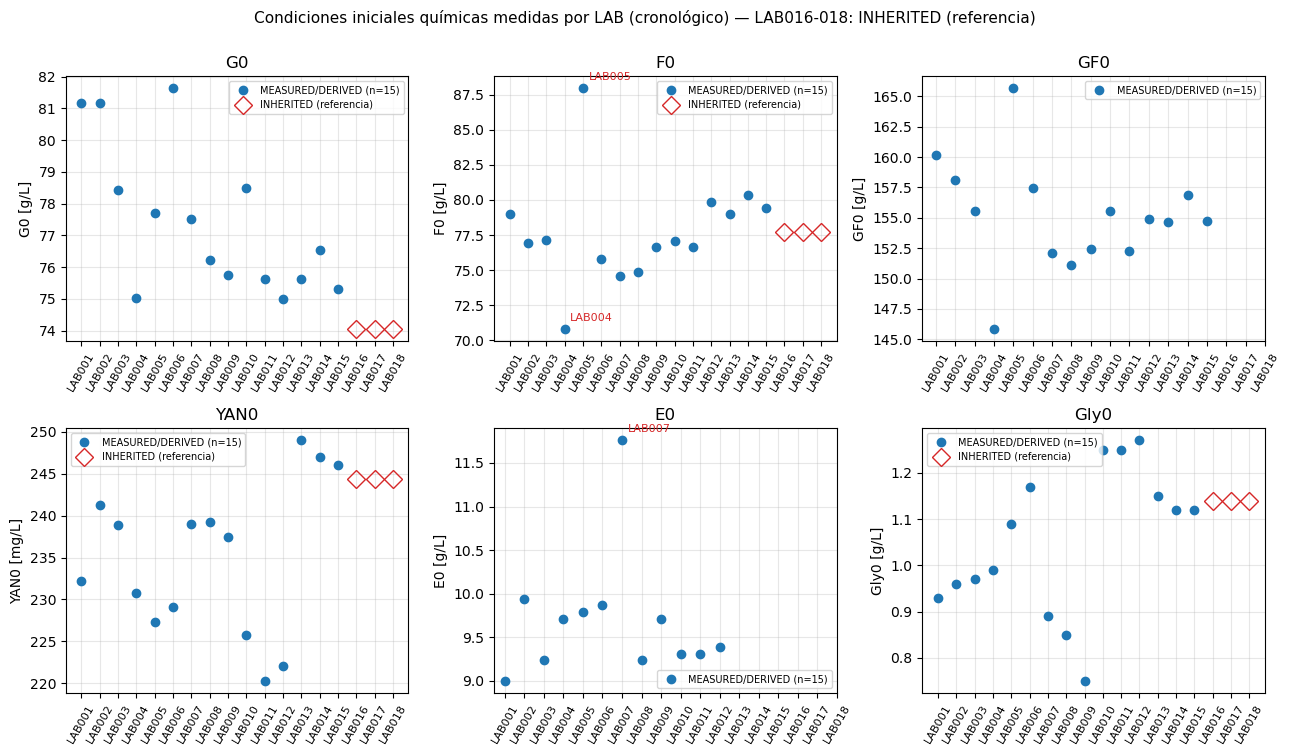

In [12]:
x = np.arange(len(LAB_ORDER))
def plot_var(ax, var, unit):
    m = measured.set_index("LAB")
    labs_m = [l for l in LAB_ORDER if l in m.index]
    xi = [LAB_ORDER.index(l) for l in labs_m]
    vals = [m.loc[l, var] for l in labs_m]
    ax.plot(xi, vals, "o", ms=6, color="#1f77b4", label="MEASURED/DERIVED (n=15)")
    if var in ("G0", "F0", "YAN0", "Gly0"):
        inh_labs = [l for l in LAB_ORDER if l in inh]
        ax.plot([LAB_ORDER.index(l) for l in inh_labs], [inh[l][var] for l in inh_labs],
                "D", mfc="none", ms=9, color="#d62728", label="INHERITED (referencia)")
    outl = lineage[(lineage.variable == var) & (lineage.potential_outlier)]["LAB"].tolist()
    for l in outl:
        if l in labs_m:
            ax.annotate(l, (LAB_ORDER.index(l), m.loc[l, var]), textcoords="offset points",
                        xytext=(4, 6), fontsize=8, color="#d62728")
    ax.set_xticks(x); ax.set_xticklabels(LAB_ORDER, rotation=60, fontsize=8)
    ax.set_ylabel(f"{var} [{unit}]"); ax.grid(alpha=0.3)
    ax.set_title(var)
    ax.legend(fontsize=7, loc="best")
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, var in zip(axes.ravel(), ["G0", "F0", "GF0", "YAN0", "E0", "Gly0"]):
    plot_var(ax, var, UNIT[var])
fig.suptitle("Condiciones iniciales químicas medidas por LAB (cronológico) — LAB016-018: INHERITED (referencia)", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

## 13. Gráficos por grupo: réplicas vs media de grupo (intra vs entre)

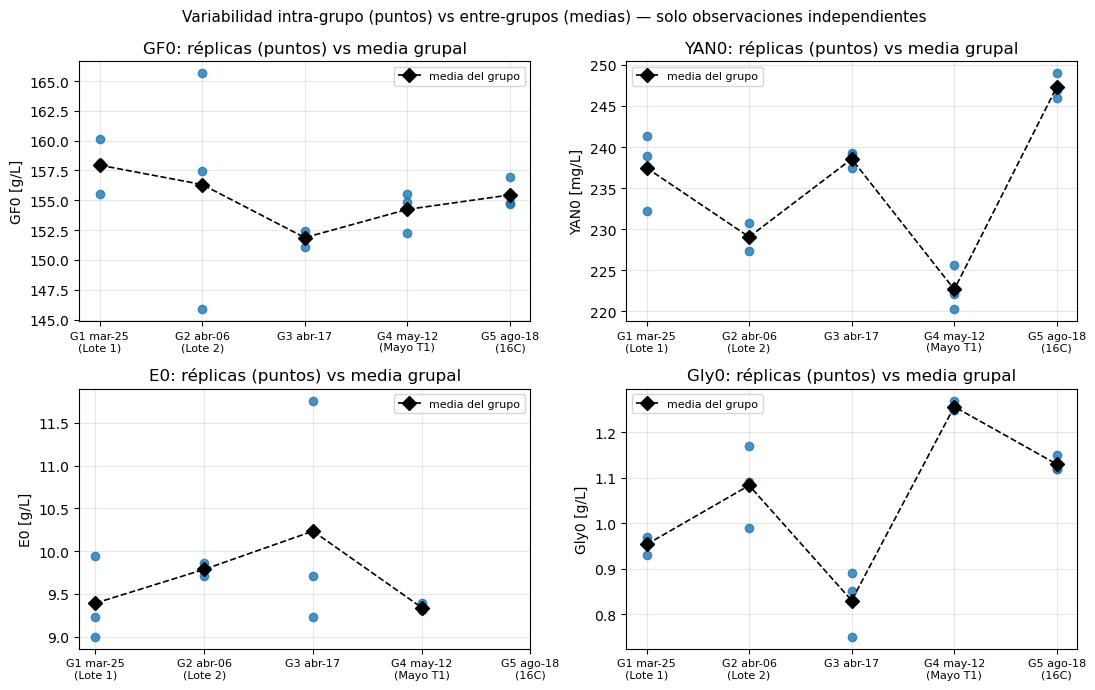

In [13]:
gorder = ["G1_Lote1_Vendimia", "G2_Lote2", "G3_abril_sin_lote", "G4_MayoT1", "G5_mem2026_16C"]
glabels = ["G1 mar-25\n(Lote 1)", "G2 abr-06\n(Lote 2)", "G3 abr-17", "G4 may-12\n(Mayo T1)", "G5 ago-18\n(16C)"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), ["GF0", "YAN0", "E0", "Gly0"]):
    means = []
    for gi, g in enumerate(gorder):
        s = measured[measured.grupo_o_lote == g][var].dropna()
        ax.plot([gi] * len(s), s, "o", ms=6, color="#1f77b4", alpha=0.8)
        if len(s):
            means.append((gi, s.mean()))
    ax.plot([m[0] for m in means], [m[1] for m in means], "kD--", ms=7, lw=1.2, label="media del grupo")
    ax.set_xticks(range(len(glabels))); ax.set_xticklabels(glabels, fontsize=8)
    ax.set_ylabel(f"{var} [{UNIT[var]}]"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_title(f"{var}: réplicas (puntos) vs media grupal")
fig.suptitle("Variabilidad intra-grupo (puntos) vs entre-grupos (medias) — solo observaciones independientes", fontsize=11)
fig.tight_layout()
plt.show()

## 14. Análisis específico de E0 (etanol inicial)

Instrumento/método: **Alcolyzer** (columna `Cf Alcolyzer Real (% v/v)` = valor corregido; bruto
≈ ×1.20–1.25 según corrección sistemática del método, auditoría §3.3). Unidad original % v/v;
conversión a g/L con el factor del loader (7.8924). Preguntas: cobertura, variación intra/entre
grupos, tendencia cronológica y compatibilidad de E0 = 0.

In [14]:
e0 = measured[["LAB", "fecha", "grupo_o_lote", "E0"]].dropna(subset=["E0"]).copy()
e0["E0_pct_vv"] = e0["E0"] / ETHANOL_G_L_PER_PERCENT_VV
e0["delta_t_h"] = e0["LAB"].map(lambda l: GROUPS[l]["delta_t"])
display(e0.round(3))
print("Instrumento: Alcolyzer (Cf Alcolyzer Real). Unidad nativa % v/v -> g/L x 7.8924 (loader).")
print("Cobertura E0:", len(e0), "de 18 LAB;", measured["E0"].isna().sum(), "LAB sin medicion (013-018) + 3 heredados")
g = e0.groupby("grupo_o_lote")["E0"].agg(["count", "mean", "std", "min", "max"])
display(g.round(3))
s_all = e0["E0"]
print(f"Global: mean={s_all.mean():.3f} g/L ({s_all.mean()/ETHANOL_G_L_PER_PERCENT_VV:.3f} % v/v), "
      f"std={s_all.std(ddof=1):.3f}, min={s_all.min():.3f}, max={s_all.max():.3f}")
sens = e0[~e0.LAB.isin(["LAB010", "LAB011", "LAB012"])]["E0"]
print(f"Sensibilidad sin LAB010-012 (procedencia primaria no trazable): n={len(sens)}, mean={sens.mean():.3f}, std={sens.std(ddof=1):.3f} g/L")
print("Medias por grupo en orden cronologico:",
      [f"{gi}: {e0[e0.grupo_o_lote == gi]['E0'].mean():.2f}" for gi in gorder if not np.isnan(e0[e0.grupo_o_lote == gi]['E0'].mean())])
print("[RESULTADO DESCRIPTIVO] Todas las mediciones estan entre",
      f"{s_all.min():.2f} y {s_all.max():.2f} g/L ({s_all.min()/ETHANOL_G_L_PER_PERCENT_VV:.2f}-{s_all.max()/ETHANOL_G_L_PER_PERCENT_VV:.2f} % v/v).")
print("[HECHO VERIFICADO] Se midio alcohol inicial distinto de cero en las 12 fermentaciones con Alcolyzer.")
print("[INTERPRETACION] E0=0 NO es compatible con las mediciones; si es compatible como escenario limite de sensibilidad (así lo usa el holdout).")
print("[CAUSA del alcohol preexistente] NO demostrada (espontanea pre-inoculacion vs formacion previa vs interferencia del metodo).")

,LAB,fecha,grupo_o_lote,E0,E0_pct_vv,delta_t_h
0,LAB001,2026-03-25,G1_Lote1_Vendimia,8.997,1.14,-2.0
1,LAB002,2026-03-25,G1_Lote1_Vendimia,9.944,1.26,-2.0
2,LAB003,2026-03-25,G1_Lote1_Vendimia,9.234,1.17,-2.0
3,LAB004,2026-04-06,G2_Lote2,9.708,1.23,0.0
4,LAB005,2026-04-06,G2_Lote2,9.787,1.24,0.0
5,LAB006,2026-04-06,G2_Lote2,9.866,1.25,0.0
6,LAB007,2026-04-17,G3_abril_sin_lote,11.760,1.49,0.0
7,LAB008,2026-04-17,G3_abril_sin_lote,9.234,1.17,0.0
8,LAB009,2026-04-17,G3_abril_sin_lote,9.708,1.23,0.0
9,LAB010,2026-05-12,G4_MayoT1,9.313,1.18,0.0


Instrumento: Alcolyzer (Cf Alcolyzer Real). Unidad nativa % v/v -> g/L x 7.8924 (loader).
Cobertura E0: 12 de 18 LAB; 3 LAB sin medicion (013-018) + 3 heredados


,count,mean,std,min,max
grupo_o_lote,,,,,
G1_Lote1_Vendimia,3,9.392,0.493,8.997,9.944
G2_Lote2,3,9.787,0.079,9.708,9.866
G3_abril_sin_lote,3,10.234,1.342,9.234,11.760
G4_MayoT1,3,9.339,0.046,9.313,9.392


Global: mean=9.688 g/L (1.227 % v/v), std=0.717, min=8.997, max=11.760
Sensibilidad sin LAB010-012 (procedencia primaria no trazable): n=9, mean=9.804, std=0.804 g/L
Medias por grupo en orden cronologico: ['G1_Lote1_Vendimia: 9.39', 'G2_Lote2: 9.79', 'G3_abril_sin_lote: 10.23', 'G4_MayoT1: 9.34']
[RESULTADO DESCRIPTIVO] Todas las mediciones estan entre 9.00 y 11.76 g/L (1.14-1.49 % v/v).
[HECHO VERIFICADO] Se midio alcohol inicial distinto de cero en las 12 fermentaciones con Alcolyzer.
[INTERPRETACION] E0=0 NO es compatible con las mediciones; si es compatible como escenario limite de sensibilidad (así lo usa el holdout).
[CAUSA del alcohol preexistente] NO demostrada (espontanea pre-inoculacion vs formacion previa vs interferencia del metodo).


## 15. YAN0 vs N0 (y la deuda del factor 0.82)

- YAN0 medido/derivado según grupo (secc. 6). N0 = YAN0·10⁻³ siempre DERIVED (loader
  `new_must_data_loader.py:245`); **no es una observación independiente**.
- Fórmula del repo: `YAN = PAN + 0.82·Amonio` (workbook xthiol `00_Resumen`); el Y15 de agosto
  reporta `YAN_mg_L` directamente. Verificación de consistencia por LAB a continuación.
- [CONFLICTO conocido, NO corregir aquí] la reconstrucción por componentes del código
  (`new_must_data_loader.py:252-253`) usa `PAN + NH4` **sin** el 0.82 (deuda documentada en
  `docs/natural_must_model_calibration_and_estimator_readiness_2026.md` §11.3).
- Para comparar el mosto se usa el YAN (medido cuando existe).

In [15]:
ver = []
for lab in LAB_ORDER[:15]:
    g = GROUPS[lab]["grupo"][:2]
    if g == "G1":
        d = data1.loc[lab]
    elif g in ("G2", "G3", "G4"):
        d = data2.loc[lab]
    else:
        d = data3.loc[lab]
    yan_f = d["PAN0"] + YAN_NH3_TO_N * d["NH40"]
    ver.append(dict(LAB=lab, PAN0=d["PAN0"], NH4_ion=d["NH40"], YAN_reportado=d["YAN0"],
                    YAN_formula=yan_f, residuo=d["YAN0"] - yan_f))
verif = pd.DataFrame(ver)
display(verif.round(3))
print("Max |residuo| YAN_reportado - (PAN+0.82*NH4):", verif.residuo.abs().max().round(3), "mg/L")
print("Conclusion: YAN de todos los grupos es consistente con la misma formula (<=0.6 mg/L).")
print("N0 = YAN0*1e-3 en todos los casos; N0 jamas se cuenta como observacion independiente de YAN0.")

,LAB,PAN0,NH4_ion,YAN_reportado,YAN_formula,residuo
0,LAB001,92.0,171.0,232.22,232.22,0.0
1,LAB002,97.0,176.0,241.32,241.32,0.0
2,LAB003,97.0,173.0,238.86,238.86,0.0
3,LAB004,93.0,168.0,230.76,230.76,0.0
4,LAB005,92.0,165.0,227.30,227.30,0.0
5,LAB006,93.0,166.0,229.12,229.12,0.0
6,LAB007,98.0,172.0,239.04,239.04,0.0
7,LAB008,99.0,171.0,239.22,239.22,0.0
8,LAB009,98.0,170.0,237.40,237.40,0.0
9,LAB010,115.0,135.0,225.70,225.70,0.0


Max |residuo| YAN_reportado - (PAN+0.82*NH4): 0.6 mg/L
Conclusion: YAN de todos los grupos es consistente con la misma formula (<=0.6 mg/L).
N0 = YAN0*1e-3 en todos los casos; N0 jamas se cuenta como observacion independiente de YAN0.


## 16. X0 / Xd0 (documentados, pero NO son propiedad química del mosto)

X0/Xd0 dependen del protocolo de inoculación, viabilidad y momento de muestreo. Se documentan en
el linaje y aquí, con las mediciones Oculyze cercanas a inoculación que existen para LAB013–018
(no usadas por los notebooks, que aplican fallback 0.45/0). **No se usan para evaluar estabilidad
química del mosto.**

,conc,viab_pct,X_est,description,X0_usado,X0_status
LAB013,15.21,90.15,0.411354,18/08/2026 10:00,0.45,FALLBACK
LAB014,15.44,94.28,0.436705,18/08/2026 10:00,0.45,FALLBACK
LAB015,17.36,92.04,0.479344,18/08/2026 10:00,0.45,FALLBACK
LAB016,14.75,97.66,0.432145,01/09/26 10:00,0.45,FALLBACK
LAB017,9.02,88.94,0.240672,01/09/2026 10:00,0.45,FALLBACK
LAB018,9.29,92.56,0.257965,19/01/26 10:00,0.45,FALLBACK


Oculyze LAB013-015 muestra 1 (~10:00-11:33, pre/incierta respecto de inoculacion);
Oculyze LAB016-018 muestra 1 (2026-09-01 ~09:00 = +8.9 h post-t0): medicion cercana pero POSTERIOR a t0.


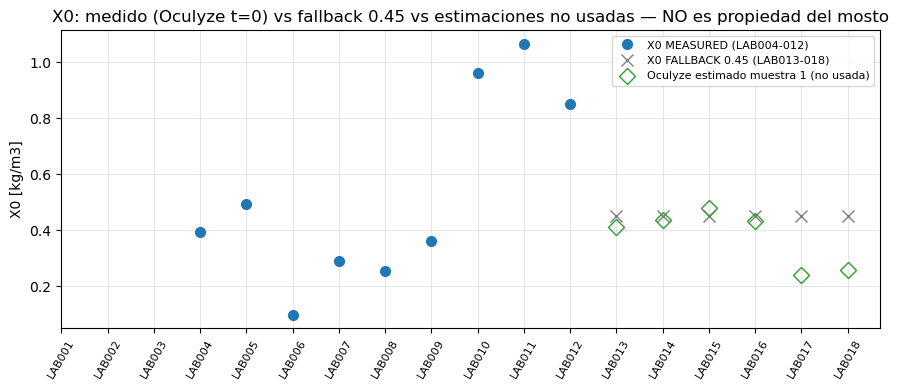

[RESULTADO DESCRIPTIVO] X0 medido varia 0.099-1.066 kg/m3 (LAB004-012): refleja protocolo de inoculacion, no quimica del mosto.


In [16]:
ocu_est = {}
for n in range(13, 19):
    lab = f"LAB0{n}"
    rep = pd.read_csv(OCU_DIRS[n])
    r1 = rep.iloc[0]  # muestra 1 (la mas temprana registrada)
    conc, viab = float(r1["Concentration"]), float(r1["Viability"])
    ocu_est[lab] = dict(conc=conc, viab_pct=viab, X_est=conc * viab / 100 * MCELLSML_TO_KGM3,
                        description=str(r1["Description"]))
ocu_df = pd.DataFrame(ocu_est).T
x_used = lineage[lineage.variable == "X0"][["LAB", "value", "status"]].set_index("LAB")
tab = ocu_df.join(x_used.rename(columns={"value": "X0_usado", "status": "X0_status"}))
display(tab.round(3))
print("Oculyze LAB013-015 muestra 1 (~10:00-11:33, pre/incierta respecto de inoculacion);")
print("Oculyze LAB016-018 muestra 1 (2026-09-01 ~09:00 = +8.9 h post-t0): medicion cercana pero POSTERIOR a t0.")
x0m = lineage[(lineage.variable == "X0") & (lineage.status == "MEASURED")]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([LAB_ORDER.index(l) for l in x0m["LAB"]], x0m["value"], "o", ms=7, color="#1f77b4", label="X0 MEASURED (LAB004-012)")
fx = lineage[(lineage.variable == "X0") & (lineage.status == "FALLBACK")]
ax.plot([LAB_ORDER.index(l) for l in fx["LAB"]], fx["value"], "x", ms=8, color="#7f7f7f", label="X0 FALLBACK 0.45 (LAB013-018)")
oe = [(l, v) for l, v in ocu_est.items()]
ax.plot([LAB_ORDER.index(l) for l, _ in oe], [v["X_est"] for _, v in oe], "D", mfc="none", ms=8,
        color="#2ca02c", label="Oculyze estimado muestra 1 (no usada)")
ax.set_xticks(np.arange(18)); ax.set_xticklabels(LAB_ORDER, rotation=60, fontsize=8)
ax.set_ylabel("X0 [kg/m3]"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("X0: medido (Oculyze t=0) vs fallback 0.45 vs estimaciones no usadas — NO es propiedad del mosto")
plt.tight_layout(); plt.show()
print("[RESULTADO DESCRIPTIVO] X0 medido varia 0.099-1.066 kg/m3 (LAB004-012): refleja protocolo de inoculacion, no quimica del mosto.")

## 17. Semántica temporal de las mediciones usadas como IC

Ninguna medición está lejos de su inoculación salvo por los casos marcados; LAB013–015 tienen Δt
no cuantificable (hora de inoculación NO DOCUMENTADA) y LAB016–018 no tienen medición propia.

In [17]:
sem = measured[["LAB", "fecha", "grupo_o_lote", "delta_t_quimica_inoculacion_h"]].copy()
sem["inoculacion"] = sem["LAB"].map(lambda l: GROUPS[l]["inoc"])
sem["fuente_inoculacion"] = sem["LAB"].map(lambda l: GROUPS[l]["inoc_src"])
sem["quimica_dt"] = sem["LAB"].map(lambda l: GROUPS[l]["chem_dt"])
sem["nota"] = sem["LAB"].map(lambda l: GROUPS[l]["nota"])
display(sem)
print("Puntos cuya medicion NO es estrictamente una condicion en el instante de inoculacion:")
print(" - LAB001-003: quimica 2 h ANTES de inocular (pre-inoculo).")
print(" - LAB004-006: quimica EN t0 por construccion (hora de siembra con conflicto +/-2 h).")
print(" - LAB010-012: delta_t=0 solo bajo la grilla de hojas LAB*; seria +5 h bajo Datos_homologados (conflicto interno).")
print(" - LAB013-015: PI pre-inoculo con hora de inoculacion NO documentada (delta_t NaN).")

,LAB,fecha,grupo_o_lote,delta_t_quimica_inoculacion_h,inoculacion,fuente_inoculacion,quimica_dt,nota
0,LAB001,2026-03-25,G1_Lote1_Vendimia,-2.0,2026-03-25 18:00,Planilla 03_Eventos (ejecución) + Maestro hora,2026-03-25 16:00,Química L-01 pre-inóculo (hito 04_Muestreo_MEF)
1,LAB002,2026-03-25,G1_Lote1_Vendimia,-2.0,2026-03-25 18:00,ídem,2026-03-25 16:00,ídem
2,LAB003,2026-03-25,G1_Lote1_Vendimia,-2.0,2026-03-25 18:00,ídem,2026-03-25 16:00,ídem
3,LAB004,2026-04-06,G2_Lote2,0.0,2026-04-06 13:00,xthiol Eventos (Fecha-hora); CONFLICTO 10:00/1...,2026-04-06 13:00,t=0 quimico = t=0 modelo (por construccion); i...
4,LAB005,2026-04-06,G2_Lote2,0.0,2026-04-06 13:00,ídem,2026-04-06 13:00,ídem
5,LAB006,2026-04-06,G2_Lote2,0.0,2026-04-06 13:00,ídem,2026-04-06 13:00,ídem
6,LAB007,2026-04-17,G3_abril_sin_lote,0.0,2026-04-17 16:00,ICS 20:00Z=16:00 local (Eventos xthiol dice 03...,2026-04-17 16:00,t0 modelo = primer muestreo (regla homologacion)
7,LAB008,2026-04-17,G3_abril_sin_lote,0.0,2026-04-17 16:00,ídem,2026-04-17 16:00,ídem
8,LAB009,2026-04-17,G3_abril_sin_lote,0.0,2026-04-17 16:00,ídem,2026-04-17 16:00,ídem
9,LAB010,2026-05-12,G4_MayoT1,0.0,2026-05-12 ~15:00,CONFLICTO: workbook 10:00 vs ICS 14:45-15:45 l...,2026-05-12 15:00,delta_t=0 en hojas LAB*; seria +5 h bajo Datos...


Puntos cuya medicion NO es estrictamente una condicion en el instante de inoculacion:
 - LAB001-003: quimica 2 h ANTES de inocular (pre-inoculo).
 - LAB004-006: quimica EN t0 por construccion (hora de siembra con conflicto +/-2 h).
 - LAB010-012: delta_t=0 solo bajo la grilla de hojas LAB*; seria +5 h bajo Datos_homologados (conflicto interno).
 - LAB013-015: PI pre-inoculo con hora de inoculacion NO documentada (delta_t NaN).


## 18. Conclusiones (generadas desde los datos de este notebook)

In [18]:
def status_labs(var, st):
    return lineage[(lineage.variable == var) & (lineage.status == st)]["LAB"].tolist()
print("1) LAB con ICs quimicas realmente MEASURED (G0/F0/Gly0):", ", ".join(status_labs("G0", "MEASURED")))
print("2) LAB con DERIVED desde medicion propia (N0; YAN0 en 001-012; E0 g/L en 001-012):", ", ".join(sorted(set(status_labs("N0", "DERIVED")))))
print("3) LAB con valores INHERITED:", ", ".join(sorted(set(status_labs("G0", "INHERITED")))), "(G0/F0/YAN0/N0/Gly0)")
print("4) LAB con FALLBACK (E0 en 013-015; X0/Xd0 en 013-018): LAB013-018")
print("5) LAB con SCENARIO (E0 A/B):", ", ".join(sorted(set(status_labs("E0", "SCENARIO")))))
print("6) Observaciones independientes: " + ", ".join(f"{v}: {int(gstats.loc[v,'n'])}" for v in ["G0","F0","GF0","YAN0","E0","Gly0"]))
print("   (GF0 es composicion de G0+F0; N0 replica a YAN0 en otras unidades)")
print("7) Similitud entre grupos (medias):")
for v in ["GF0", "YAN0", "E0", "Gly0"]:
    sub = by_batch[by_batch.variable == v]
    print(f"   {v}: medias {', '.join(f'{m:.2f}' for m in sub.mean_group)} (rango {sub.mean_group.max()-sub.mean_group.min():.2f})")
print("8) Clasificacion descriptiva (criterio declarado: CV total <5% poca; 5-10% moderada; >10% importante):")
crit = lambda cv: "poca" if cv < 5 else ("moderada" if cv <= 10 else "importante")
for v in ["G0", "F0", "GF0", "YAN0", "E0", "Gly0"]:
    cv = gstats.loc[v, "CV_percent"]
    r = comp.loc[v, "ratio_between_over_within"] if v in comp.index else np.nan
    print(f"   {v}: CV={cv:.1f}% -> {crit(cv)}; ratio entre/intra grupos={r:.2f}")
print("9) Intra vs entre grupos (ratio between/within):")
for v in comp.index:
    print(f"   {v}: {comp.loc[v,'ratio_between_over_within']:.2f}")
print("10) Outliers IQR:", flagged if flagged else "ninguno")
mono = {v: abs(by_batch[by_batch.variable == v].sort_values("fecha")["mean_group"].diff().dropna().mean()) for v in ["GF0","YAN0","E0","Gly0"]}
print("11) Deriva temporal: las medias grupales en orden cronologico son (arriba); ",
      "ninguna variable muestra progresion monotona consistente con tiempo de almacenamiento.",
      "GF0: intra-grupo domina; YAN0/Gly0: entre-grupos domina pero NO monotono (baja en mayo, sube en agosto).")
print("12) E0=0:", f"NO compatible: n={int(gstats.loc['E0','n'])} mediciones entre {gstats.loc['E0','min']:.2f} y {gstats.loc['E0','max']:.2f} g/L (1.14-1.49 % v/v).")
print("13) NO son observaciones quimicas independientes: LAB016, LAB017, LAB018 (todas sus ICs quimicas heredadas).")
print("14) Cobertura para recalibracion: GF0/YAN0/Gly0 n=15; E0 n=12 (9 con procedencia primaria trazable + 3 con salvedad); X0 n=9 (LAB004-012).")
print("15) Informacion que sigue faltando: hora de inoculacion LAB013-015 (y conflicta de horas 004-006/010-012); E0 de agosto-septiembre;",
      "origen del ETANOL 1.18/1.19 de LAB010-012; metadata del mosto madre (vendimia/conservacion/tratamientos); dosis de nutricion LAB016-018.")

1) LAB con ICs quimicas realmente MEASURED (G0/F0/Gly0): LAB001, LAB002, LAB003, LAB004, LAB005, LAB006, LAB007, LAB008, LAB009, LAB010, LAB011, LAB012, LAB013, LAB014, LAB015
2) LAB con DERIVED desde medicion propia (N0; YAN0 en 001-012; E0 g/L en 001-012): LAB001, LAB002, LAB003, LAB004, LAB005, LAB006, LAB007, LAB008, LAB009, LAB010, LAB011, LAB012, LAB013, LAB014, LAB015
3) LAB con valores INHERITED: LAB016, LAB017, LAB018 (G0/F0/YAN0/N0/Gly0)
4) LAB con FALLBACK (E0 en 013-015; X0/Xd0 en 013-018): LAB013-018
5) LAB con SCENARIO (E0 A/B): LAB016, LAB017, LAB018
6) Observaciones independientes: G0: 15, F0: 15, GF0: 15, YAN0: 15, E0: 12, Gly0: 15
   (GF0 es composicion de G0+F0; N0 replica a YAN0 en otras unidades)
7) Similitud entre grupos (medias):
   GF0: medias 157.94, 156.32, 151.87, 154.23, 155.45 (rango 6.08)
   YAN0: medias 237.47, 229.06, 238.55, 222.67, 247.33 (rango 24.67)
   E0: medias 9.39, 9.79, 10.23, 9.34 (rango 0.89)
   Gly0: medias 0.95, 1.08, 0.83, 1.26, 1.13 (rang

## 19. Interpretación final (resumen científico)

[RESULTADO DESCRIPTIVO] La química inicial medida del mosto natural (15 observaciones
independientes en 5 fechas, marzo–agosto 2026) es **aproximadamente común** en sus azúcares
(GF0 = 155 ± 4 g/L, CV ≈ 3%, con la variabilidad intra-grupo dominando la entre-grupos) y en su
alcohol preexistente (E0 = 1.1–1.5 % v/v, plano en el tiempo). YAN0 (CV total ≈ 4%) y Gly0
(CV ≈ 15%) muestran **estructura entre grupos** (medias desplazadas más allá de la dispersión de
réplicas) pero **sin monotonía temporal**: baja de abril a mayo y sube en agosto. Eso es
compatible con efectos de manejo/lote/análisis entre campañas, no con una deriva direccional del
mosto durante el almacenamiento.

[INTERPRETACIÓN] Con esta evidencia: (i) GF0 y E0 pueden tratarse como propiedades comunes del
mosto dentro de la dispersión medida; (ii) YAN0 y Gly0 admiten un valor común solo con una
desviación experimental mayor declarada (±5% y ±20% respecto de la media global); (iii) no hay soporte para
modelar ICs en función de la fecha; (iv) imponer E0 = 0 contradice 12 mediciones; (v) X0/Xd0 son
por experimento. Los valores heredados de LAB016–018 deben seguir tratándose como lo que son:
una sola observación del 18-08 replicada en tres simulaciones, no tres mediciones.

Detalle, fuentes por cifra y conflictos: `docs/natural_must_temporal_audit_LAB001_018.md`
(§ nueva sección cuantitativa).